## KNN Algorithm

#### Step 1: Visualizing the data as a starting point


As a starting point we used Class distripution to visulaize the data.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

#Our dataset is made up of many .txt files, so first we convert it into a dataset.
base_dir = 'overall/overall/overall'

def load_texts(folder, label):
    folder_path = os.path.join(base_dir, folder)
    texts=[]

    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path= os.path.join(folder_path, filename)
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                texts.append(f.read())
    return pd.DataFrame({"text": texts, "label": label})

#We loaded each category of training data: fake, and legit seperately. 
fakeDF= load_texts("fake", 0)
legitDF = load_texts("real", 1) #Where 0 would indicate fake news, and 1 indicate real ones.

#Then combined them into one connected dataframe.
df = pd.concat([fakeDF, legitDF], ignore_index= True)

print(df.head())
print(df["label"].value_counts)

                                                text  label
0  Kim Kardashian Changed Her Password Again Afte...      0
1  ‘Bird Box’ Challenge: Man Crashes After Attemp...      0
2  29 Humans Killed in Laboratory\nProducing Mili...      0
3  Bart Simpson elected mayor of LA town\nThe Sim...      0
4  Jaden Smith Says He is a Prophet and God Inspi...      0
<bound method IndexOpsMixin.value_counts of 0      0
1      0
2      0
3      0
4      0
      ..
575    1
576    1
577    1
578    1
579    1
Name: label, Length: 580, dtype: int64>


C:\Users\shaha\AppData\Local\Temp\ipykernel_28456\693601356.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


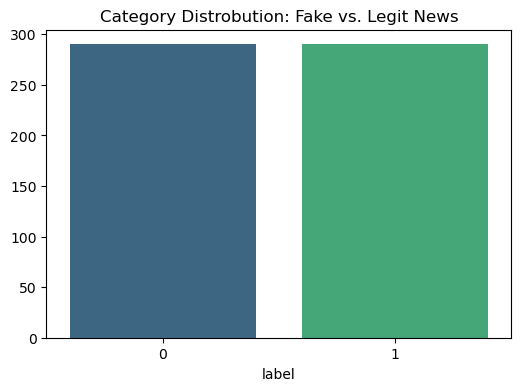

In [17]:
counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.title("Category Distrobution: Fake vs. Legit News")
plt.show()

We can observe that the number of data entries for both fake and real news are fairly close in number. 

#### Step 2: Performing Term Frequency - Inverse Document Frequency (TF-IDF)

In an aim to find the words that are most important in diffrentiating between real and fake news.

In [18]:
from sklearn.model_selection import train_test_split

#splitting the dataset to start, to work cleanly. 

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], 
    df["label"], 
    test_size= 0.2, 
    random_state= 42, 
    stratify= df["label"]
)

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Taking the shortcut to converting text values to numerical values. 
vectorizer = TfidfVectorizer(
    stop_words= "english", 
    max_features= 5000, #limiting the size
    ngram_range= (1,2) 
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.fit_transform(X_test)

In [20]:
#Checking that everything is in order: 
print("Training vector shape:", X_train_vec.shape)
print("Testing vector shape:", X_test_vec.shape)

Training vector shape: (464, 5000)
Testing vector shape: (116, 5000)


We made each news article -data entry- a numerical vector to fit it to KNN.

#### Step 3: Training K-Nearest Neighbours

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train a k-NN classifier
knn = KNeighborsClassifier(n_neighbors=7) #Chose the value of 7 as it gave us the best possible accuracy.
knn.fit(X_train_vec, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test_vec)
print(f"Test Accuracy (k=5): {accuracy_score(y_test, y_pred):.2f}")

Test Accuracy (k=5): 0.55


#### Average‑Case Example

In [25]:
example = ['''Several online posts claimed that new transportation plans were approved this week,
but no official announcement has been released. Some users said they heard about the changes from unnamed sources.''']

example_vec = vectorizer.transform(example)

fakeReal= "Real" if knn.predict(example_vec) else "Fake" 

print("KNN Predects that the Example is", fakeReal )

KNN Predects that the Example is Fake


I chose this example because it is a neutral news text with slight uncertainty
making it suitable for testing the average case where algorithms may disagree